Dataset sintético para detección de fraude


Variables clave para detección de fraude:

- transaction_id: ID único
- amount: Monto de la transacción (USD)
- hour_of_day: Hora del día (0-23)
- day_of_week: Día de la semana (0-6)
- customer_age: Edad del cliente
- account_balance: Saldo actual de la cuenta
- transaction_type: Tipo ('online', 'in_store', 'atm')
- merchant_category: Categoría del comercio (e.g., 'grocery', 'online_retail', 'travel')
- distance_from_home: Distancia desde la ubicación habitual (km)
- is_foreign: Si es transacción extranjera (0/1)
- device_type: Tipo de dispositivo ('mobile', 'desktop', 'atm')
- num_recent_transactions: Transacciones en las últimas 24h
- is_fraud: Target (1: fraude, 0: legítima) - Generado con lógica para simular patrones reales

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from xgboost import XGBClassifier, cv
from xgboost import DMatrix
from imblearn.over_sampling import SMOTE  # Para oversampling de la clase minoritaria (fraude)
import shap  # Para explicabilidad (pip install shap)
import warnings
warnings.filterwarnings('ignore')

/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Generar dataset mejorado (más realista)
def generate_fraud_data(num_records=100000):
    np.random.seed(42)
    
    data = {}
    data['transaction_id'] = np.arange(1, num_records + 1)
    data['amount'] = np.random.lognormal(4.5, 1.2, num_records)
    data['hour_of_day'] = np.random.choice(range(24), num_records, p=[0.02]*8 + [0.05]*8 + [0.055]*8)
    data['customer_id'] = np.random.randint(1, 20000, num_records)  # Clientes repetidos para agregados
    data['customer_age'] = np.random.randint(18, 81, num_records)
    data['account_balance'] = np.clip(np.random.normal(5000, 3000, num_records), 0, None)
    data['transaction_type'] = np.random.choice(['online', 'in_store', 'atm'], num_records, p=[0.5, 0.4, 0.1])
    data['distance_from_home'] = np.abs(np.random.normal(5, 20, num_records))
    data['merchant_category'] = np.random.choice(['grocery', 'online_retail', 'travel', 'entertainment', 'fuel'], num_records)
    data['device_type'] = np.random.choice(['mobile', 'desktop', 'atm'], num_records, p=[0.6, 0.3, 0.1])
    data['is_foreign'] = np.random.choice([0, 1], num_records, p=[0.95, 0.05])
    data['device_new'] = np.random.choice([0, 1], num_records, p=[0.9, 0.1])  # Dispositivo nuevo (riesgo)
    data['velocity_24h'] = np.random.poisson(2, num_records)  # Transacciones en 24h
    
    # Fraude más realista
    fraud_prob = (
        0.001 +
        0.015 * (data['amount'] > np.percentile(data['amount'], 95)) +
        0.025 * np.isin(data['hour_of_day'], [0,1,2,3,4,5]) +
        0.04 * (data['distance_from_home'] > 50) +
        0.05 * data['is_foreign'] +
        0.03 * data['device_new'] +
        0.02 * (data['velocity_24h'] > 10)
    )
    data['is_fraud'] = np.random.binomial(1, np.clip(fraud_prob, 0, 0.99))
    
    df = pd.DataFrame(data)
    return df

fraud_df = generate_fraud_data()

In [5]:
fraud_df.to_csv('bank_fraud_transactions.csv', index=False)

In [12]:
#fraud_df = pd.read_csv("./bank_fraud_transactions.csv")
fraud_df

,transaction_id,amount,hour_of_day,customer_id,customer_age,account_balance,transaction_type,distance_from_home,merchant_category,device_type,is_foreign,device_new,velocity_24h,is_fraud
0,1,163.376440,10,12791,38,6998.700124,online,16.010599,travel,atm,0,0,2,0
1,2,76.254989,18,3585,53,6104.711505,in_store,24.618249,fuel,mobile,0,0,3,0
2,3,195.825948,8,19094,72,6781.952610,online,12.177224,online_retail,mobile,0,0,1,0
3,4,559.831490,20,5062,19,6608.084046,online,23.119854,travel,mobile,0,0,3,0
4,5,67.966569,4,12879,37,0.000000,online,9.195840,online_retail,desktop,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,68.698686,2,2502,19,4527.047741,online,23.533293,travel,mobile,0,0,0,0
99996,99997,45.434283,17,14196,51,7379.636359,in_store,12.475102,entertainment,mobile,0,0,4,0
99997,99998,147.086683,18,18746,54,6720.242838,in_store,9.706488,online_retail,mobile,0,0,3,0
99998,99999,69.873747,16,6158,35,4012.114816,online,5.640494,entertainment,mobile,0,1,2,0


In [13]:
fraud_df.columns

Index(['transaction_id', 'amount', 'hour_of_day', 'customer_id',
       'customer_age', 'account_balance', 'transaction_type',
       'distance_from_home', 'merchant_category', 'device_type', 'is_foreign',
       'device_new', 'velocity_24h', 'is_fraud'],
      dtype='object')

In [15]:
fraud_df.drop(columns= ['device_new', 'velocity_24h',])

,transaction_id,amount,hour_of_day,customer_id,customer_age,account_balance,transaction_type,distance_from_home,merchant_category,device_type,is_foreign,is_fraud
0,1,163.376440,10,12791,38,6998.700124,online,16.010599,travel,atm,0,0
1,2,76.254989,18,3585,53,6104.711505,in_store,24.618249,fuel,mobile,0,0
2,3,195.825948,8,19094,72,6781.952610,online,12.177224,online_retail,mobile,0,0
3,4,559.831490,20,5062,19,6608.084046,online,23.119854,travel,mobile,0,0
4,5,67.966569,4,12879,37,0.000000,online,9.195840,online_retail,desktop,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,68.698686,2,2502,19,4527.047741,online,23.533293,travel,mobile,0,0
99996,99997,45.434283,17,14196,51,7379.636359,in_store,12.475102,entertainment,mobile,0,0
99997,99998,147.086683,18,18746,54,6720.242838,in_store,9.706488,online_retail,mobile,0,0
99998,99999,69.873747,16,6158,35,4012.114816,online,5.640494,entertainment,mobile,0,0


In [4]:
# Paso 2: Análisis Exploratorio de Datos (EDA) - Solo columnas numéricas para correlación
print("\nEstadísticas descriptivas:")
print(fraud_df.describe())


Estadísticas descriptivas:
       transaction_id         amount    hour_of_day    customer_id  \
count   100000.000000  100000.000000  100000.000000  100000.000000   
mean     50000.500000     185.066792      13.778100   10002.831810   
std      28867.657797     326.511917       6.212517    5784.289849   
min          1.000000       0.423702       0.000000       1.000000   
25%      25000.750000      40.069175       9.000000    4981.750000   
50%      50000.500000      90.303799      14.000000    9998.000000   
75%      75000.250000     202.815691      19.000000   15043.000000   
max     100000.000000   19436.365511      23.000000   19999.000000   

        customer_age  account_balance  distance_from_home     is_foreign  \
count  100000.000000    100000.000000       100000.000000  100000.000000   
mean       49.065600      5057.831028           16.516720       0.049190   
std        18.148463      2884.056576           12.476410       0.216266   
min        18.000000         0.000000

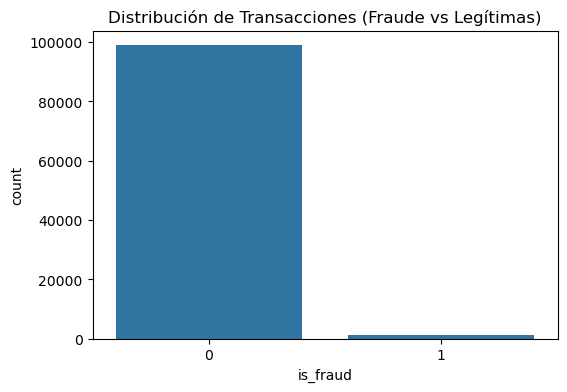

In [5]:
# Distribución de fraude
# is_fraud: Target (1: fraude, 0: legítima) - Generado con lógica para simular patrones reales

plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=fraud_df)
plt.title('Distribución de Transacciones (Fraude vs Legítimas)')
plt.show()

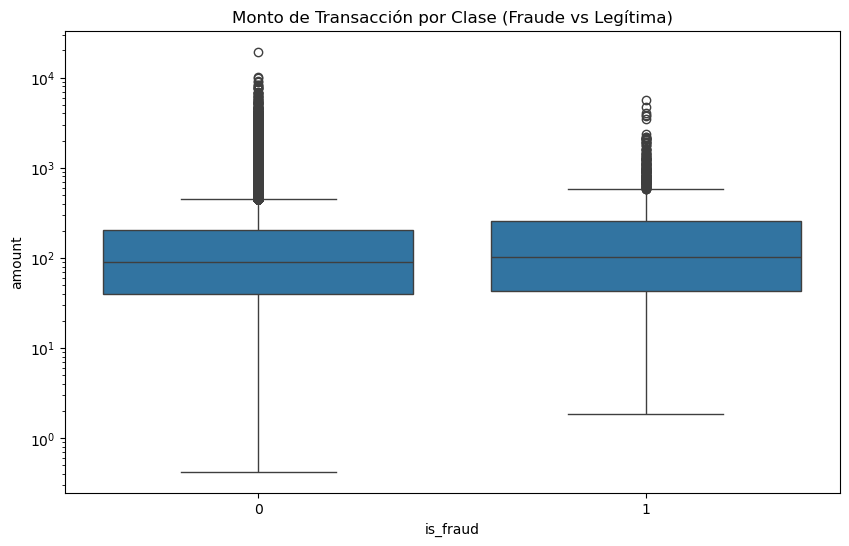

In [6]:
# Monto por tipo de transacción y fraude
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amount', data=fraud_df)
plt.title('Monto de Transacción por Clase (Fraude vs Legítima)')
plt.yscale('log')
plt.show()

In [7]:
# Correlación con fraude - SOLO COLUMNAS NUMÉRICAS (corrección clave)
numeric_cols = fraud_df.select_dtypes(include=[np.number]).columns
fraud_corr = fraud_df[numeric_cols].corr()['is_fraud'].sort_values(ascending=False)
print("\nCorrelación con 'is_fraud' (solo variables numéricas):")
print(fraud_corr)


Correlación con 'is_fraud' (solo variables numéricas):
is_fraud              1.000000
is_foreign            0.096076
device_new            0.087002
amount                0.029041
distance_from_home    0.020615
customer_id           0.002583
velocity_24h          0.000648
account_balance      -0.000713
customer_age         -0.001162
transaction_id       -0.003700
hour_of_day          -0.053356
Name: is_fraud, dtype: float64


In [8]:
# Feature Engineering realista
# Agregados por cliente (promedio histórico)
customer_stats = fraud_df.groupby('customer_id')['amount'].mean().reset_index(name='avg_amount_customer')
fraud_df = fraud_df.merge(customer_stats, on='customer_id')
fraud_df['amount_ratio'] = fraud_df['amount'] / fraud_df['avg_amount_customer']  # Anomaly detection

In [9]:
fraud_df

,transaction_id,amount,hour_of_day,customer_id,customer_age,account_balance,transaction_type,distance_from_home,merchant_category,device_type,is_foreign,device_new,velocity_24h,is_fraud,avg_amount_customer,amount_ratio
0,1,163.376440,10,12791,38,6998.700124,online,16.010599,travel,atm,0,0,2,0,193.799013,0.843020
1,2,76.254989,18,3585,53,6104.711505,in_store,24.618249,fuel,mobile,0,0,3,0,123.180189,0.619052
2,3,195.825948,8,19094,72,6781.952610,online,12.177224,online_retail,mobile,0,0,1,0,168.732348,1.160571
3,4,559.831490,20,5062,19,6608.084046,online,23.119854,travel,mobile,0,0,3,0,147.845208,3.786606
4,5,67.966569,4,12879,37,0.000000,online,9.195840,online_retail,desktop,0,0,2,0,79.974196,0.849856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,68.698686,2,2502,19,4527.047741,online,23.533293,travel,mobile,0,0,0,0,264.247353,0.259979
99996,99997,45.434283,17,14196,51,7379.636359,in_store,12.475102,entertainment,mobile,0,0,4,0,158.374291,0.286879
99997,99998,147.086683,18,18746,54,6720.242838,in_store,9.706488,online_retail,mobile,0,0,3,0,373.518647,0.393787
99998,99999,69.873747,16,6158,35,4012.114816,online,5.640494,entertainment,mobile,0,1,2,0,140.520709,0.497249


In [10]:
# Paso 3: Preprocesamiento
cat_cols = ['transaction_type', 'merchant_category', 'device_type']
fraud_df = pd.get_dummies(fraud_df, columns=cat_cols)

In [11]:
fraud_df

,transaction_id,amount,hour_of_day,customer_id,customer_age,account_balance,distance_from_home,is_foreign,device_new,velocity_24h,...,transaction_type_in_store,transaction_type_online,merchant_category_entertainment,merchant_category_fuel,merchant_category_grocery,merchant_category_online_retail,merchant_category_travel,device_type_atm,device_type_desktop,device_type_mobile
0,1,163.376440,10,12791,38,6998.700124,16.010599,0,0,2,...,False,True,False,False,False,False,True,True,False,False
1,2,76.254989,18,3585,53,6104.711505,24.618249,0,0,3,...,True,False,False,True,False,False,False,False,False,True
2,3,195.825948,8,19094,72,6781.952610,12.177224,0,0,1,...,False,True,False,False,False,True,False,False,False,True
3,4,559.831490,20,5062,19,6608.084046,23.119854,0,0,3,...,False,True,False,False,False,False,True,False,False,True
4,5,67.966569,4,12879,37,0.000000,9.195840,0,0,2,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,68.698686,2,2502,19,4527.047741,23.533293,0,0,0,...,False,True,False,False,False,False,True,False,False,True
99996,99997,45.434283,17,14196,51,7379.636359,12.475102,0,0,4,...,True,False,True,False,False,False,False,False,False,True
99997,99998,147.086683,18,18746,54,6720.242838,9.706488,0,0,3,...,True,False,False,False,False,True,False,False,False,True
99998,99999,69.873747,16,6158,35,4012.114816,5.640494,0,1,2,...,False,True,True,False,False,False,False,False,False,True


In [12]:
# Features y target
X = fraud_df.drop(columns=['transaction_id', 'is_fraud', 'customer_id',])
y = fraud_df['is_fraud']

In [13]:
X

,amount,hour_of_day,customer_age,account_balance,distance_from_home,is_foreign,device_new,velocity_24h,avg_amount_customer,amount_ratio,...,transaction_type_in_store,transaction_type_online,merchant_category_entertainment,merchant_category_fuel,merchant_category_grocery,merchant_category_online_retail,merchant_category_travel,device_type_atm,device_type_desktop,device_type_mobile
0,163.376440,10,38,6998.700124,16.010599,0,0,2,193.799013,0.843020,...,False,True,False,False,False,False,True,True,False,False
1,76.254989,18,53,6104.711505,24.618249,0,0,3,123.180189,0.619052,...,True,False,False,True,False,False,False,False,False,True
2,195.825948,8,72,6781.952610,12.177224,0,0,1,168.732348,1.160571,...,False,True,False,False,False,True,False,False,False,True
3,559.831490,20,19,6608.084046,23.119854,0,0,3,147.845208,3.786606,...,False,True,False,False,False,False,True,False,False,True
4,67.966569,4,37,0.000000,9.195840,0,0,2,79.974196,0.849856,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,68.698686,2,19,4527.047741,23.533293,0,0,0,264.247353,0.259979,...,False,True,False,False,False,False,True,False,False,True
99996,45.434283,17,51,7379.636359,12.475102,0,0,4,158.374291,0.286879,...,True,False,True,False,False,False,False,False,False,True
99997,147.086683,18,54,6720.242838,9.706488,0,0,3,373.518647,0.393787,...,True,False,False,False,False,True,False,False,False,True
99998,69.873747,16,35,4012.114816,5.640494,0,1,2,140.520709,0.497249,...,False,True,True,False,False,False,False,False,False,True


In [14]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: is_fraud, Length: 100000, dtype: int64

In [15]:
# Paso 4: Validación Cruzada con XGBoost
dtrain = DMatrix(X, label=y)

# definimos algunos parametros del modelo
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (len(y) - sum(y)) / sum(y)
}

print("Iniciando Validación Cruzada (5 folds) con XGBoost...")
cv_results = cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,
    nfold=5,
    stratified=True,
    early_stopping_rounds=20,
    metrics=['aucpr', 'auc'],
    seed=42,
    verbose_eval=20
)

Iniciando Validación Cruzada (5 folds) con XGBoost...
[0]	train-aucpr:0.05808+0.00464	train-auc:0.85685+0.00241	test-aucpr:0.03884+0.00396	test-auc:0.78846+0.02484
[20]	train-aucpr:0.12133+0.00822	train-auc:0.92168+0.00251	test-aucpr:0.04072+0.00351	test-auc:0.82786+0.01105
[37]	train-aucpr:0.19158+0.01100	train-auc:0.94377+0.00240	test-aucpr:0.04026+0.00286	test-auc:0.82551+0.00989


In [16]:
print("\nResultados de Validación Cruzada:")
cv_results


Resultados de Validación Cruzada:


,train-aucpr-mean,train-aucpr-std,train-auc-mean,train-auc-std,test-aucpr-mean,test-aucpr-std,test-auc-mean,test-auc-std
0,0.058085,0.004638,0.856849,0.002414,0.038837,0.003961,0.788458,0.024842
1,0.063936,0.001340,0.872361,0.002421,0.040162,0.005966,0.811262,0.019697
2,0.066486,0.001535,0.876658,0.002594,0.036571,0.002337,0.817412,0.015571
3,0.074039,0.002957,0.884274,0.001739,0.038992,0.003944,0.821490,0.015528
4,0.072927,0.002297,0.886065,0.001982,0.036989,0.002618,0.816558,0.014043
5,0.076488,0.002838,0.888827,0.001375,0.036143,0.001736,0.818854,0.012261
6,0.079554,0.004646,0.891444,0.001638,0.037101,0.003236,0.823992,0.013413
7,0.082122,0.004475,0.891412,0.002084,0.038756,0.003857,0.826442,0.014711
8,0.088632,0.004788,0.898523,0.001340,0.040667,0.004175,0.828185,0.015120
9,0.091224,0.002323,0.901735,0.001517,0.038903,0.003235,0.826277,0.014437


In [17]:
best_num_boost_round = len(cv_results)
print(f"\nMejor número de árboles: {best_num_boost_round}")
print(f"PR-AUC promedio (test): {cv_results['test-aucpr-mean'].iloc[-1]:.4f} ± {cv_results['test-aucpr-std'].iloc[-1]:.4f}")
print(f"ROC-AUC promedio (test): {cv_results['test-auc-mean'].iloc[-1]:.4f} ± {cv_results['test-auc-std'].iloc[-1]:.4f}")


Mejor número de árboles: 19
PR-AUC promedio (test): 0.0415 ± 0.0046
ROC-AUC promedio (test): 0.8302 ± 0.0125


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Paso 4: Aplicar SMOTE al set de entrenamiento para balancear clases
# SMOTE genera muestras sintéticas de la clase minoritaria (fraude=1)
# Solo en train para evitar leakage
smote = SMOTE(random_state=42, sampling_strategy='minority')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE (train):")
print(pd.Series(y_train_smote).value_counts(normalize=True))


Distribución después de SMOTE (train):
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64



Distribución después de SMOTE (train):
is_fraud
0    0.989263
1    0.010738
Name: proportion, dtype: float64


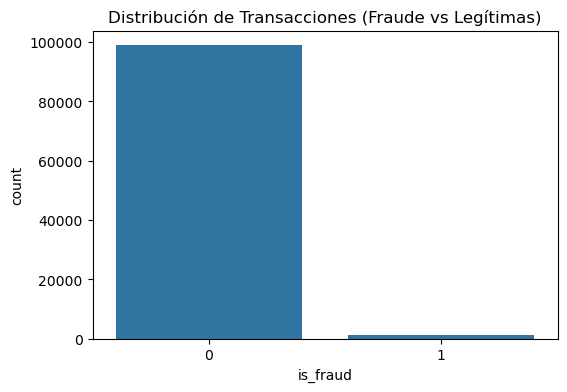

In [20]:
# Distribución de fraude
# is_fraud: Target (1: fraude, 0: legítima) - Generado con lógica para simular patrones reales

print("\nDistribución después de SMOTE (train):")
print(pd.Series(y_train).value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=fraud_df)
plt.title('Distribución de Transacciones (Fraude vs Legítimas)')
plt.show()

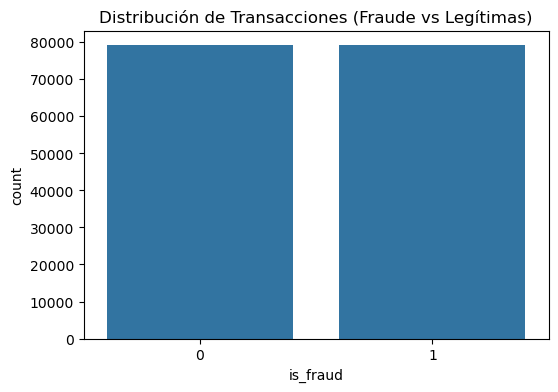

In [22]:
# Distribución de fraude
# is_fraud: Target (1: fraude, 0: legítima) - Generado con lógica para simular patrones reales

plt.figure(figsize=(6, 4))
sns.countplot(x= y_train_smote, )
plt.title('Distribución de Transacciones (Fraude vs Legítimas)')
plt.show()

In [23]:
final_model = XGBClassifier(n_estimators=200, scale_pos_weight=(y_train == 0).sum() / y_train.sum(), random_state=42)

In [24]:




# entrenamos el modelo usando el metodo fit
#final_model.fit(X_train, y_train)

final_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# Evaluación final
#y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob > 0.5).astype(int)  # Threshold inicial

print("\nEvaluación Final en Test Set:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Evaluación Final en Test Set:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     19785
           1       0.04      0.17      0.07       215

    accuracy                           0.95     20000
   macro avg       0.52      0.56      0.52     20000
weighted avg       0.98      0.95      0.96     20000

ROC-AUC: 0.6145


In [26]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Precision-Recall AUC: 0.0230


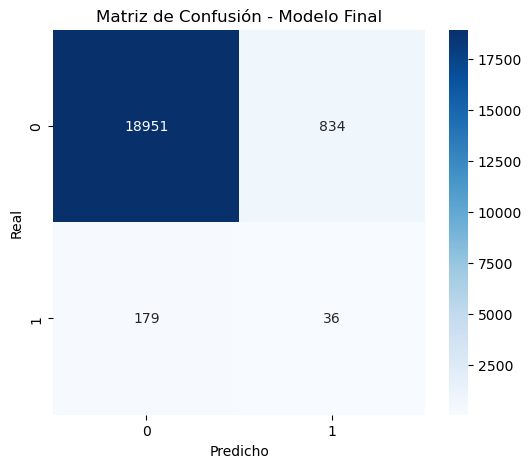

In [27]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Modelo Final')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

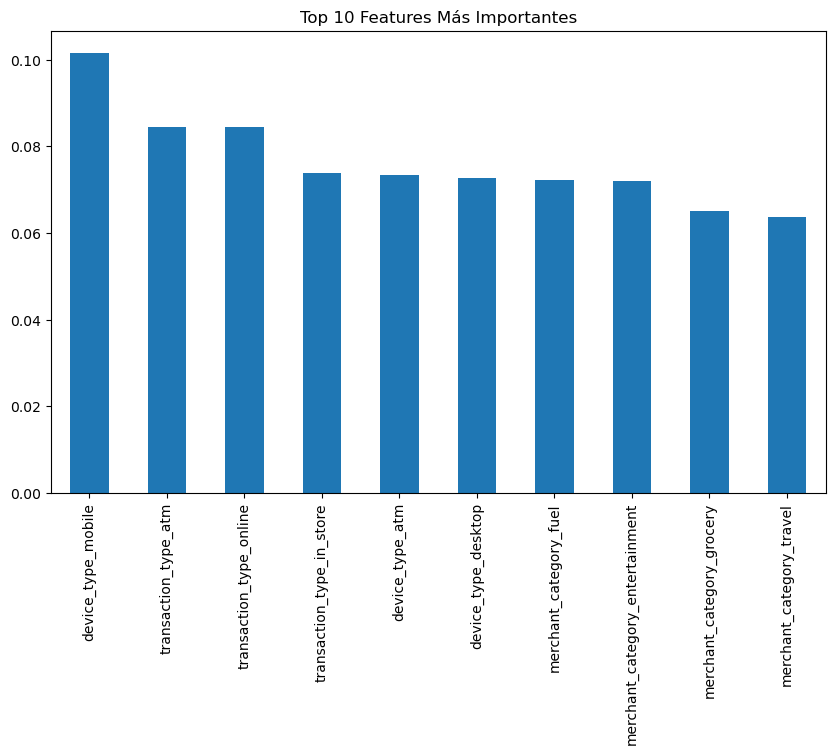

In [28]:
# Importancia de features
feature_importance = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='bar')
plt.title('Top 10 Features Más Importantes')
plt.show()

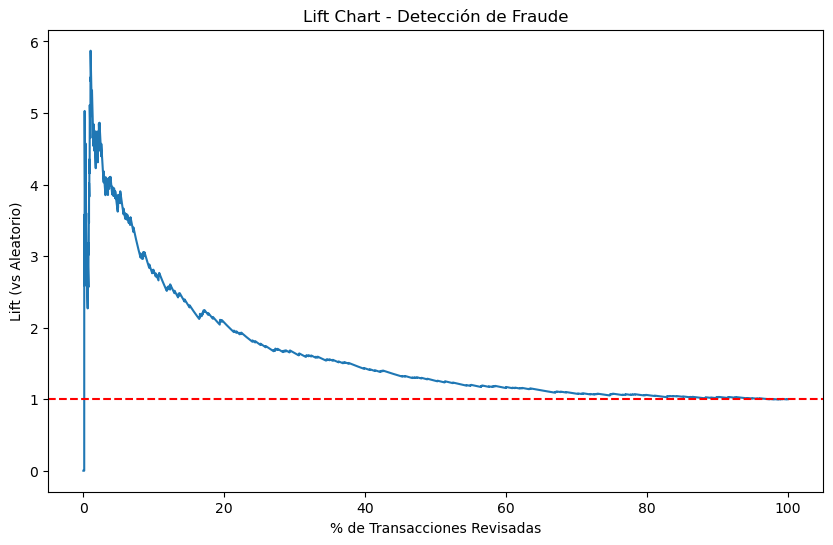

In [29]:
# Lift Chart
df_lift = pd.DataFrame({'prob': y_prob, 'actual': y_test})
df_lift = df_lift.sort_values('prob', ascending=False)
df_lift['cum_fraud'] = df_lift['actual'].cumsum()
df_lift['cum_total'] = np.arange(1, len(df_lift) + 1)
df_lift['lift'] = df_lift['cum_fraud'] / (df_lift['cum_total'] * y_test.mean())

plt.figure(figsize=(10, 6))
plt.plot(df_lift['cum_total'] / len(df_lift) * 100, df_lift['lift'])
plt.title('Lift Chart - Detección de Fraude')
plt.xlabel('% de Transacciones Revisadas')
plt.ylabel('Lift (vs Aleatorio)')
plt.axhline(1, color='red', linestyle='--')
plt.show()

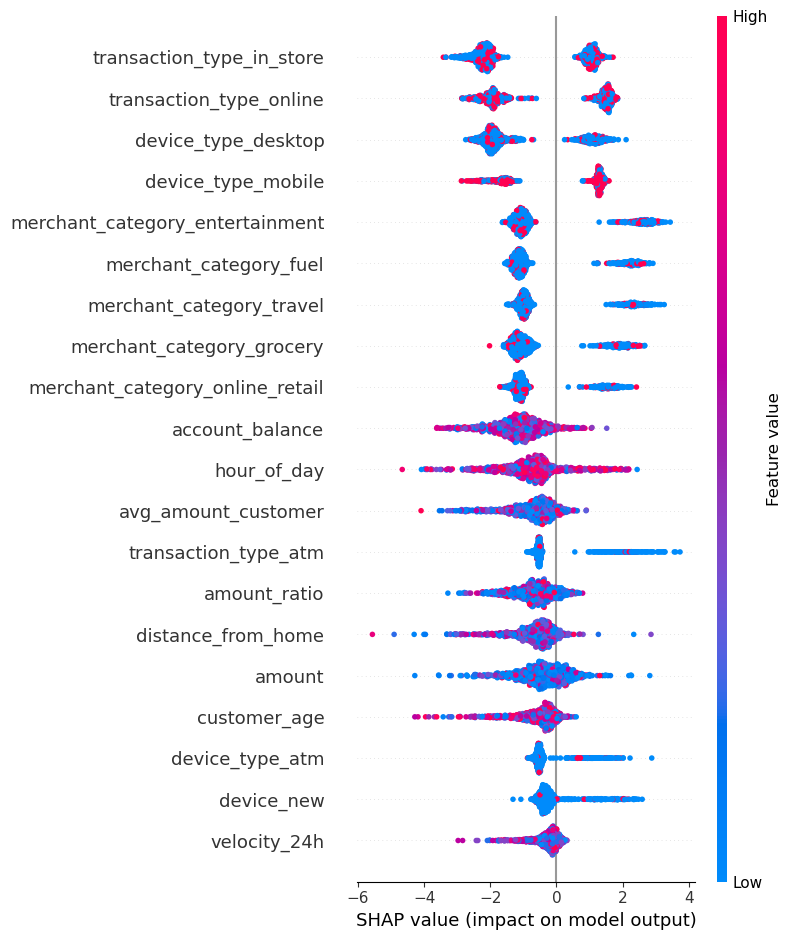

In [30]:
# Explicabilidad con SHAP
explainer = shap.Explainer(final_model)
shap_values = explainer(X_test.sample(1000))  # Muestra para velocidad
shap.summary_plot(shap_values, X_test.sample(1000))

In [ ]:
st.markdown("""<style>
    .main { background-color: #f0f4f8; }  /* Fondo principal cambiado a gris claro suave para mejor visibilidad de textos */
    .stButton>button { background-color: #0056b3; color: white; border-radius: 5px; transition: background-color 0.3s; }
    .stButton>button:hover { background-color: #003f88; }
    .stSlider .stSliderLabel { color: #333333; font-family: Arial, sans-serif; }
    .stSelectbox { background-color: #ffffff; border: 1px solid #ced4da; border-radius: 5px; }
    h1, h2, h3 { color: #1a1a1a; font-family: Arial, sans-serif; }
    .sidebar .sidebar-content { background-color: #e9ecef; box-shadow: 2px 0 5px rgba(0,0,0,0.1); }  /* Fondo sidebar gris medio para contraste */
    .block-container { padding: 20px; background-color: "#6fab6c"; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
    body { color: #333333; }  /* Asegurar texto oscuro para legibilidad */
</style>
""", unsafe_allow_html=True)